In [ ]:
import dzialania_rozmyte
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

class ZbiorRozmyty:
    '''
    Klasa tworzy przestrzeń i zawiera słownik zbiorów rozmytych.

    Argumenty:
      xp - początek przedziału przestrzeni X
      xk - koniec przedziału przestrzeni X
      step - krok - jak gęsto będzie podzielona przestrzeń X
      nazwa - nazwa rodziny zbiorów rozmytych

    Atrybuty:
      przestrzen - lista - przestrzeń X przedstawiona w sposób dyskretny [xp, xp+step, ... xk]
      zbiory - słownik zawierający zbiory rozmyte określone na przestrzeni X
      nazwa - nazwa rodziny zbiorów rozmytych
    '''
    def __init__(self, xp, xk, step, nazwa):
        self.przestrzen = [el for el in range(xp, xk+step, step)]
        self.zbiory = {}
        self.nazwa = nazwa

    def nowy_zbior_rozmyty(self, a0, a1, b1, b0, nazwa, max_wysokosc = 1):
        '''
        Funkcja dodaje nowy zbiór rozmyty do przestrzeni.
        '''
        zbior = (a0, a1, b1, b0)
        self.zbiory[nazwa] = (zbior, max_wysokosc)

    def nowy_zbior_rozmyty_punkty(self, nazwa, tablica_wartosci):
        '''
        Funkcja dodaje nowy zbiór rozmyty do przestrzeni.
        '''
        self.zbiory[nazwa] = (tablica_wartosci, max(tablica_wartosci))

    def zbior_rozmyty_wartosc(self, a0, a1, b1, b0, x, max_wysokosc = 1 ):
        '''
        Funkcja oblicza wartosc funkcji przynależności zbioru rozmytego dla zadanego punktu x.
        '''
        linia_a = ZbiorRozmyty.funkcja_liniowa([a0, 0], [a1, max_wysokosc])##współczynniki a, b
        linia_b = ZbiorRozmyty.funkcja_liniowa([b1, max_wysokosc], [b0, 0])
        if (x >= self.przestrzen[0] and x <= a0) or (x >= b0 and x <= self.przestrzen[-1]):
            return 0
        elif x >= a0 and x <= a1:
          if a0 != a1:
            return linia_a[0]*x + linia_a[1]
          else:
            return linia_a
        elif x >= b1 and x <= b0:
          if b0 != b1:
            return linia_b[0]*x + linia_b[1]
          else:
            return linia_b
        elif x >= a1 and x <= b1:
          return max_wysokosc

    @staticmethod
    def funkcja_liniowa(c, d):
        '''
        Funkcja służy do wyznaczana równania prostej przechodzącej przez dwa punkty c i d.

        Argumenty:
          c, d - krotki lub listy zawierające współrzędne punktów, przez które przechodzi prosta.

        Wynik:
          Funkcja zwraca krotkę zawierającą wartości współczynników funkcji liniowej ax + b przechodzącej przez
          punkty c i d gdy d[0] jest różne od c[0] lub wartość d[0] jeżeli prosta ma równanie x=d[0]
          tzn. jest prostopadła do osi OX.
        '''

        if d[0] - c[0] != 0:
          a = (d[1] - c[1]) / (d[0] - c[0])
          b = -a*c[0] + c[1]
          return (a, b)
        else:
          return d[0]

    def zbior_rozmyty_wykres(self, nazwa,  kolor = 'blue'):
        '''
        Funkcja rysuje wykres zbioru rozmytego i zapisuje go w pliku. Funkcja rysuje odcinki, słuzy tylko do zbiorów w kształce trapezów lub trójkątów.

        Arg:
          nazwa: nazwa zbioru rozmytego, to będzie nazzwa pliku z wynikiem
          max_w: wyskość zbioru rozmytego (największa wartość funkcji)
          kolor: kolor wykresu.
        '''
        a0, a1, b1, b0 =  self.zbiory[nazwa][0]
        max_wysokosc = self.zbiory[nazwa][1]
        plt.plot([self.przestrzen[0], a0], [0, 0],  color=kolor)
        if self.przestrzen[0] != a1:
          plt.plot([a0, a1], [0, max_wysokosc], color=kolor)
        plt.plot([a1, b1], [max_wysokosc, max_wysokosc], label=nazwa, color=kolor)
        if self.przestrzen[-1] != b1:
          plt.plot([b1, b0], [max_wysokosc, 0], color=kolor)
        plt.plot([b0, self.przestrzen[-1]], [0, 0],  color=kolor)
        plt.legend()
        #plt.savefig(nazwa)


    def __str__(self):
      wynik = f"Rodzina zbiorów rozmytych {self.nazwa},"
      for k,v in self.zbiory.items():
        wynik += f"\n  {k,v}"
      return wynik

    def get_zbiory(self):
      return self.zbiory

    def get_zbior(self, nazwa):
      return self.zbiory[nazwa]
  ### Częśc 2- punkt - po punkcie

    def wyznacz_liste_wartosci_zbioru(self, nazwa):
        """
        Funkcja tworzy listę wartości dla zbioru rozmytgo.
        """
        a0, a1, b1, b0 = self.zbiory[nazwa][0]
        max_wysokosc = self.zbiory[nazwa][1]
        #print(self.zbiory[nazwa][0])
        if a0 == self.przestrzen[0] and a1 == self.przestrzen[0]:
            a0 = self.przestrzen[0] - 1
        if b0 == self.przestrzen[-1] and b1 == self.przestrzen[-1]:
            b0 = self.przestrzen[-1] + 1

        zbior = [self.zbior_rozmyty_wartosc(a0, a1, b1, b0, i, max_wysokosc ) for i in self.przestrzen]
        return zbior

    def zbior_rozmyty_wykres_punkty(self, nazwa, plik =True, kolor = 'blue'):
        '''
        Funkcja rysuje wykres danego zbioru rozmytego punkt po punkcie i zapisuje go w pliku o nazwie podanej jako pierwszy argument..

        Arg:
          nazwa: nazwa zbioru rozmytego
          plik: jeżeli ustawiony na True rysunek zostanie zapisany w pliku
        '''
        if nazwa[0:2] != "P_": ## P_ oznacza punktowy -są to zbiory, które powstały w wyniku działań i były wyznaczane punkt po punkcie
                               ### zatem jeżeli zbiór nie jest pamiętany jako lista punktów tylko jako krotka (a0,a1,b1, b0) to wyznaczamy listę wartości
          zbior = self.wyznacz_liste_wartosci_zbioru(nazwa)
          #print("Kontrola wartosci")
          #print(zbior)

        else:
          zbior = self.zbiory[nazwa][0]
         # print(zbior)
        plt.plot(self.przestrzen, zbior, label = nazwa, color = kolor)
        #plt.legend()
       # if plik:
         # plt.savefig(nazwa)
        return

    def rysuj_wszystkie(self):
      kolor = ['blue', 'red', 'green', 'yellow', "black", "orange", "purple", "pink", "brown"]
      i = 0
      print(self.zbiory)
      print(self.zbiory.keys())
      for nazwa in self.zbiory.keys():
         if nazwa[0:2] != "P_": ### uwaga w funkcji zbior_roamyty_wykres_punkty
          self.zbior_rozmyty_wykres(nazwa, kolor[i%7])
         else:
          self.zbior_rozmyty_wykres_punkty(nazwa, False, kolor[i%7])
         i += 1
         #plt.savefig(nazwa)


  ### Część 3 -Działania

    def dzialanie_zbiorow_rozmytych(self, nazwa1, nazwa2, norma = dzialania_rozmyte.T_drastyczna,  wykres=False):
        '''
        Funkcja wykonuje dane dzialanie na dwóch zbiorach rozmytych z jednej przestrzeni.
        '''
        if nazwa1[0:2] != "P_": ##################################################3
          zbior1 = self.wyznacz_liste_wartosci_zbioru(nazwa1)
        else:
          zbior1 = self.zbiory[nazwa1][0]
      ### Wyznaczamy wartości drugiego zbioru
        if nazwa2[0:2] != "P_": ##################################################3
          zbior2 = self.wyznacz_liste_wartosci_zbioru(nazwa2)
        else:
          zbior2 = self.zbiory[nazwa2][0]


        dzialanie = [norma(zbior1[i], zbior2[i]) for i in range(len(self.przestrzen))]

        nazwa_dzialania = str(norma).split(" ")[1]
        nazwa_ret = f'P_{nazwa_dzialania}({nazwa1}, {nazwa2})' ##Wyznaczenie nazwy nowego zbioru rozpoczyna się ona od P_, bo zwiera listę warosci
        max_wysokosc = max(dzialanie)

        self.zbiory[nazwa_ret] = (dzialanie, max_wysokosc)

        #if wykres == True:
         #   self.zbior_rozmyty_wykres_punkty(nazwa_ret)
        return nazwa_ret

   ###  Czesć 5  Niezbędne dla sterownika
    def dzialanie_zbiorow_rozmytych_dla_sprawdz_pomiar(self, nazwa1, nazwa2, norma = dzialania_rozmyte.T_minimum):
        '''
        Funkcja wykonuje dane dzialanie na dwóch zbiorach rozmytych z jednej przestrzeni.
        '''
        if nazwa1[0:2] != "P_": ##################################################3
          zbior1 = self.wyznacz_liste_wartosci_zbioru(nazwa1)
        else:
          zbior1 = self.zbiory[nazwa1][0]
      ### Wyznaczamy wartości drugiego zbioru
        if nazwa2[0:2] != "P_": ##################################################3
          zbior2 = self.wyznacz_liste_wartosci_zbioru(nazwa2)
        else:
          zbior2 = self.zbiory[nazwa2][0]


        dzialanie = [norma(zbior1[i], zbior2[i]) for i in range(len(self.przestrzen))]
        ### wynik jeżeli 0 to znaczy, że zbiory nie miały części wspólnej
        return max(dzialanie)

    def sprawdz_pomiar_ze_zbiorami(self, pomiar, zbiory, t_norma = dzialania_rozmyte.T_minimum):
        '''
        Funkcja zwraca zbiory, ktore mają cześc wspólną z pomiarem, wraz z wartoscia odpalenia
        '''
        odpalone_zbiory = {}

        #print(pomiar, zbiory)
        for i in zbiory:
            #print(f"Kolejny zbiór {i}")
            cz_wspolna = self.dzialanie_zbiorow_rozmytych_dla_sprawdz_pomiar(pomiar, i, t_norma)
            #print(f"cz_wspolna = {cz_wspolna}")
            if cz_wspolna != 0:
                odpalone_zbiory[i] = round(cz_wspolna,2)
        return odpalone_zbiory

    def implikacja(self, nazwa, stopien_odpalenia, implikacja):
      '''Funkcja wykonuje działanie implikacji (importowane z pliku działania) na punktowym zbiorze rozmytym i
          stopniu odpalenia.

      Arg:
        nazwa (napis): nazwa zbioru rozmytego
        stopien_odpalenia (float): stopien odpalenia
        implikacja (str): nazwa implikacji
      Out:
        krotka złożona z nazwy zbioru wejściowego z dopiskiem implikacja i krotki wartości.

      '''
      if nazwa[0:2] != "P_": ##################################################3
          zbior1 = self.wyznacz_liste_wartosci_zbioru(nazwa)
      else:
          zbior1 = self.zbiory[nazwa][0]
      nowa_nazwa = "P_"+nazwa+"_"+"Implikacja"
      dzialanie = [implikacja(zbior1[i], stopien_odpalenia) for i in range(len(self.przestrzen))]

      return (nowa_nazwa, dzialanie)


    def wyostrzenie(self, nazwa):
        '''
        Funkcja zwraca wyostrzona wartosc zwracana przez sterownik za pomoca sredniej wazonej.
        '''
        suma = 0
        waga = 0
        lista_wartosci = self.zbiory[nazwa][0]
        for i in range(len(lista_wartosci)):
            wartosc = lista_wartosci[i]
            #print(i, wartosc, self.przestrzen[i], suma, waga)
            suma += wartosc * self.przestrzen[i]
            waga += wartosc
        srednia_wazona = suma/waga
        return srednia_wazona



In [ ]:
przestrzenX = ZbiorRozmyty(0, 31, 1, 'kolejka')
przestrzenX.nowy_zbior_rozmyty(0, 0 ,0, 10, "mala_kolejka")
przestrzenX.nowy_zbior_rozmyty(5, 15 ,15, 25 , "srednia_kolejka")
przestrzenX.nowy_zbior_rozmyty(20, 30 ,30, 30, "duza_kolejka")

{'mala_kolejka': ((0, 0, 0, 10), 1), 'srednia_kolejka': ((5, 15, 15, 25), 1), 'duza_kolejka': ((20, 30, 30, 30), 1)}
dict_keys(['mala_kolejka', 'srednia_kolejka', 'duza_kolejka'])


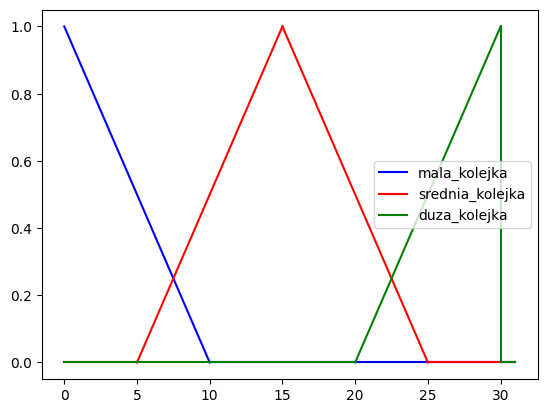

In [ ]:
przestrzenX.rysuj_wszystkie()

In [ ]:
przestrzenCzas_Oczekiwania = ZbiorRozmyty(0, 121, 1, 'czas_oczekiwania')
przestrzenCzas_Oczekiwania.nowy_zbior_rozmyty(0, 0 ,0, 40, "krotki_czas")
przestrzenCzas_Oczekiwania.nowy_zbior_rozmyty(20, 60 ,60, 100 , "sredni_czas")
przestrzenCzas_Oczekiwania.nowy_zbior_rozmyty(80, 120 ,120, 120, "dlugi_czas")

{'krotki_czas': ((0, 0, 0, 40), 1), 'sredni_czas': ((20, 60, 60, 100), 1), 'dlugi_czas': ((80, 120, 120, 120), 1)}
dict_keys(['krotki_czas', 'sredni_czas', 'dlugi_czas'])


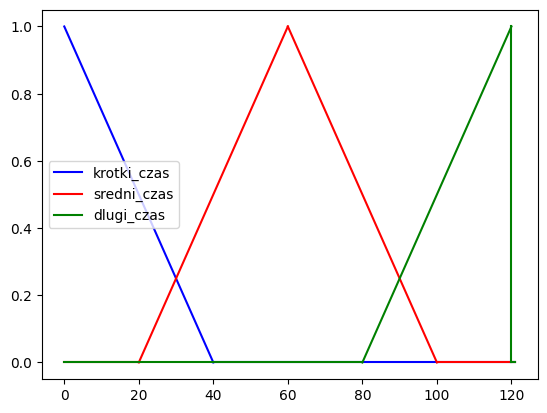

In [ ]:
przestrzenCzas_Oczekiwania.rysuj_wszystkie()

In [ ]:
przedluzenia = ZbiorRozmyty(0, 61, 1, 'czas_przedluzenia')
przedluzenia.nowy_zbior_rozmyty(0, 0, 0, 10, "brak")
przedluzenia.nowy_zbior_rozmyty(5, 20, 20, 35 , "krotki_czas_przedl")
przedluzenia.nowy_zbior_rozmyty(25, 60, 60, 60, "dlugi_czas_przedl")

{'brak': ((0, 0, 0, 10), 1), 'krotki_czas_przedl': ((5, 20, 20, 35), 1), 'dlugi_czas_przedl': ((25, 60, 60, 60), 1)}
dict_keys(['brak', 'krotki_czas_przedl', 'dlugi_czas_przedl'])


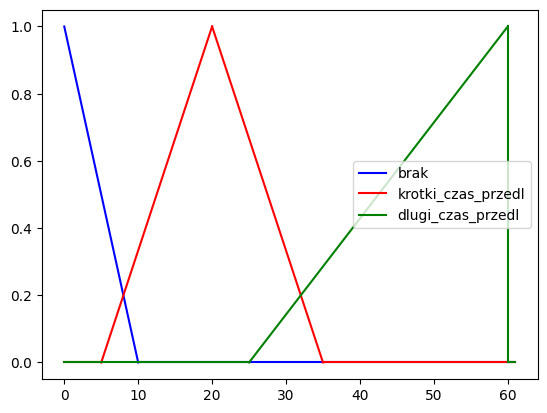

In [ ]:
przedluzenia.rysuj_wszystkie()

In [ ]:

pomiar_kolejki = 20
czas_oczekiwania = 50
baza_przestrzeniX = list(przestrzenX.get_zbiory().keys())
baza_czasu = list(przestrzenCzas_Oczekiwania.get_zbiory().keys())
print(baza_przestrzeniX)
print(baza_czasu)
przestrzenX.nowy_zbior_rozmyty(pomiar_kolejki-1, pomiar_kolejki, pomiar_kolejki, pomiar_kolejki+1, "pomiar_kolejki")
przestrzenCzas_Oczekiwania.nowy_zbior_rozmyty(czas_oczekiwania-1, czas_oczekiwania, czas_oczekiwania, czas_oczekiwania+1, "czas_oczekiwania_pomiar")
print(przestrzenX)
odpalone_x = przestrzenX.sprawdz_pomiar_ze_zbiorami('pomiar_kolejki', baza_przestrzeniX)
print(odpalone_x)
print(f"Odpalone reguły przestrzeni X to {odpalone_x}")

odpalone_czas_oczekiwania = przestrzenCzas_Oczekiwania.sprawdz_pomiar_ze_zbiorami('czas_oczekiwania_pomiar', baza_czasu)
print(odpalone_czas_oczekiwania)
print(f"Odpalone reguły przestrzeni czas to {odpalone_czas_oczekiwania}")

['mala_kolejka', 'srednia_kolejka', 'duza_kolejka']
['krotki_czas', 'sredni_czas', 'dlugi_czas']
Rodzina zbiorów rozmytych kolejka,
  ('mala_kolejka', ((0, 0, 0, 10), 1))
  ('srednia_kolejka', ((5, 15, 15, 25), 1))
  ('duza_kolejka', ((20, 30, 30, 30), 1))
  ('pomiar_kolejki', ((19, 20, 20, 21), 1))
{'srednia_kolejka': 0.5}
Odpalone reguły przestrzeni X to {'srednia_kolejka': 0.5}
{'sredni_czas': 0.75}
Odpalone reguły przestrzeni czas to {'sredni_czas': 0.75}


{'krotki_czas': ((0, 0, 0, 40), 1), 'sredni_czas': ((20, 60, 60, 100), 1), 'dlugi_czas': ((80, 120, 120, 120), 1), 'czas_oczekiwania_pomiar': ((49, 50, 50, 51), 1)}
dict_keys(['krotki_czas', 'sredni_czas', 'dlugi_czas', 'czas_oczekiwania_pomiar'])


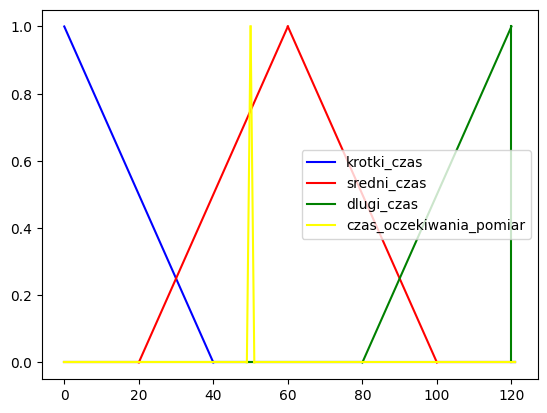

In [ ]:
przestrzenCzas_Oczekiwania.rysuj_wszystkie()

{'mala_kolejka': ((0, 0, 0, 10), 1), 'srednia_kolejka': ((5, 15, 15, 25), 1), 'duza_kolejka': ((20, 30, 30, 30), 1), 'pomiar_kolejki': ((19, 20, 20, 21), 1)}
dict_keys(['mala_kolejka', 'srednia_kolejka', 'duza_kolejka', 'pomiar_kolejki'])


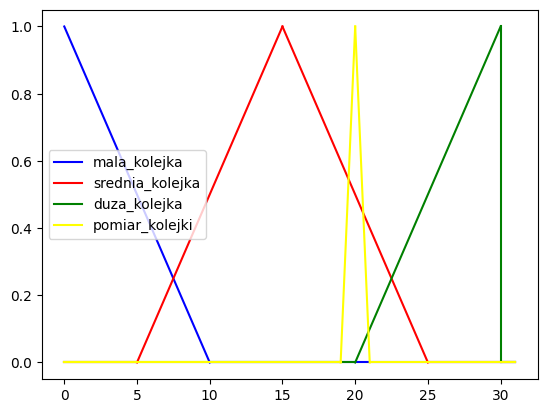

In [ ]:
przestrzenX.rysuj_wszystkie()

In [ ]:
reguly = {
    "mala_kolejka" :
     {
        "krotki_czas": "brak",
        "sredni_czas": "brak",
        "dlugi_czas": "brak"
      },
    "srednia_kolejka":
    {
        "krotki_czas": "krotki_czas_przedl",
        "sredni_czas": "krotki_czas_przedl",
        "dlugi_czas": "krotki_czas_przedl"
     },
    "duza_kolejka":
    {
        "krotki_czas": "dlugi_czas_przedl",
        "sredni_czas": "dlugi_czas_przedl",
        "dlugi_czas": "krotki_czas_przedl"
     }
}

In [ ]:
reguly = {
    "mala_kolejka" :
     {
        "krotki_czas": "brak",
        "sredni_czas": "brak",
        "dlugi_czas": "brak"
      },
    "srednia_kolejka":
    {
        "krotki_czas": "krotki_czas_przedl",
        "sredni_czas": "krotki_czas_przedl",
        "dlugi_czas": "krotki_czas_przedl"
     },
    "duza_kolejka":
    {
        "krotki_czas": "dlugi_czas_przedl",
        "sredni_czas": "dlugi_czas_przedl",
        "dlugi_czas": "krotki_czas_przedl"
     }
}
class ZbiorRozmyty:
    '''
    Klasa tworzy przestrzeń i zawiera słownik zbiorów rozmytych.

    Argumenty:
      xp - początek przedziału przestrzeni X
      xk - koniec przedziału przestrzeni X
      step - krok - jak gęsto będzie podzielona przestrzeń X
      nazwa - nazwa rodziny zbiorów rozmytych

    Atrybuty:
      przestrzen - lista - przestrzeń X przedstawiona w sposób dyskretny [xp, xp+step, ... xk]
      zbiory - słownik zawierający zbiory rozmyte określone na przestrzeni X
      nazwa - nazwa rodziny zbiorów rozmytych
    '''
    def __init__(self, xp, xk, step, nazwa):
        self.przestrzen = [el for el in range(xp, xk+step, step)]
        self.zbiory = {}
        self.nazwa = nazwa

    def nowy_zbior_rozmyty(self, a0, a1, b1, b0, nazwa, max_wysokosc = 1):
        '''
        Funkcja dodaje nowy zbiór rozmyty do przestrzeni.
        '''
        zbior = (a0, a1, b1, b0)
        self.zbiory[nazwa] = (zbior, max_wysokosc)

    def nowy_zbior_rozmyty_punkty(self, nazwa, tablica_wartosci):
        '''
        Funkcja dodaje nowy zbiór rozmyty do przestrzeni.
        '''
        self.zbiory[nazwa] = (tablica_wartosci, max(tablica_wartosci))

    def zbior_rozmyty_wartosc(self, a0, a1, b1, b0, x, max_wysokosc = 1 ):
        '''
        Funkcja oblicza wartosc funkcji przynależności zbioru rozmytego dla zadanego punktu x.
        '''
        linia_a = ZbiorRozmyty.funkcja_liniowa([a0, 0], [a1, max_wysokosc])##współczynniki a, b
        linia_b = ZbiorRozmyty.funkcja_liniowa([b1, max_wysokosc], [b0, 0])
        if (x >= self.przestrzen[0] and x <= a0) or (x >= b0 and x <= self.przestrzen[-1]):
            return 0
        elif x >= a0 and x <= a1:
          if a0 != a1:
            return linia_a[0]*x + linia_a[1]
          else:
            return linia_a
        elif x >= b1 and x <= b0:
          if b0 != b1:
            return linia_b[0]*x + linia_b[1]
          else:
            return linia_b
        elif x >= a1 and x <= b1:
          return max_wysokosc

    @staticmethod
    def funkcja_liniowa(c, d):
        '''
        Funkcja służy do wyznaczana równania prostej przechodzącej przez dwa punkty c i d.

        Argumenty:
          c, d - krotki lub listy zawierające współrzędne punktów, przez które przechodzi prosta.

        Wynik:
          Funkcja zwraca krotkę zawierającą wartości współczynników funkcji liniowej ax + b przechodzącej przez
          punkty c i d gdy d[0] jest różne od c[0] lub wartość d[0] jeżeli prosta ma równanie x=d[0]
          tzn. jest prostopadła do osi OX.
        '''

        if d[0] - c[0] != 0:
          a = (d[1] - c[1]) / (d[0] - c[0])
          b = -a*c[0] + c[1]
          return (a, b)
        else:
          return d[0]



    def __str__(self):
      wynik = f"Rodzina zbiorów rozmytych {self.nazwa},"
      for k,v in self.zbiory.items():
        wynik += f"\n  {k,v}"
      return wynik

    def get_zbiory(self):
      return self.zbiory

    def get_zbior(self, nazwa):
      return self.zbiory[nazwa]
  ### Częśc 2- punkt - po punkcie

    def wyznacz_liste_wartosci_zbioru(self, nazwa):
        """
        Funkcja tworzy listę wartości dla zbioru rozmytgo.
        """
        a0, a1, b1, b0 = self.zbiory[nazwa][0]
        max_wysokosc = self.zbiory[nazwa][1]
        #print(self.zbiory[nazwa][0])
        if a0 == self.przestrzen[0] and a1 == self.przestrzen[0]:
            a0 = self.przestrzen[0] - 1
        if b0 == self.przestrzen[-1] and b1 == self.przestrzen[-1]:
            b0 = self.przestrzen[-1] + 1

        zbior = [self.zbior_rozmyty_wartosc(a0, a1, b1, b0, i, max_wysokosc ) for i in self.przestrzen]
        return zbior



  ### Część 3 -Działania

    def dzialanie_zbiorow_rozmytych(self, nazwa1, nazwa2, norma = dzialania_rozmyte.T_drastyczna,  wykres=False):
        '''
        Funkcja wykonuje dane dzialanie na dwóch zbiorach rozmytych z jednej przestrzeni.
        '''
        if nazwa1[0:2] != "P_": ##################################################3
          zbior1 = self.wyznacz_liste_wartosci_zbioru(nazwa1)
        else:
          zbior1 = self.zbiory[nazwa1][0]
      ### Wyznaczamy wartości drugiego zbioru
        if nazwa2[0:2] != "P_": ##################################################3
          zbior2 = self.wyznacz_liste_wartosci_zbioru(nazwa2)
        else:
          zbior2 = self.zbiory[nazwa2][0]


        dzialanie = [norma(zbior1[i], zbior2[i]) for i in range(len(self.przestrzen))]

        nazwa_dzialania = str(norma).split(" ")[1]
        nazwa_ret = f'P_{nazwa_dzialania}({nazwa1}, {nazwa2})' ##Wyznaczenie nazwy nowego zbioru rozpoczyna się ona od P_, bo zwiera listę warosci
        max_wysokosc = max(dzialanie)

        self.zbiory[nazwa_ret] = (dzialanie, max_wysokosc)

        #if wykres == True:
         #   self.zbior_rozmyty_wykres_punkty(nazwa_ret)
        return nazwa_ret

   ###  Czesć 5  Niezbędne dla sterownika
    def dzialanie_zbiorow_rozmytych_dla_sprawdz_pomiar(self, nazwa1, nazwa2, norma = dzialania_rozmyte.T_minimum):
        '''
        Funkcja wykonuje dane dzialanie na dwóch zbiorach rozmytych z jednej przestrzeni.
        '''
        if nazwa1[0:2] != "P_": ##################################################3
          zbior1 = self.wyznacz_liste_wartosci_zbioru(nazwa1)
        else:
          zbior1 = self.zbiory[nazwa1][0]
      ### Wyznaczamy wartości drugiego zbioru
        if nazwa2[0:2] != "P_": ##################################################3
          zbior2 = self.wyznacz_liste_wartosci_zbioru(nazwa2)
        else:
          zbior2 = self.zbiory[nazwa2][0]


        dzialanie = [norma(zbior1[i], zbior2[i]) for i in range(len(self.przestrzen))]
        ### wynik jeżeli 0 to znaczy, że zbiory nie miały części wspólnej
        return max(dzialanie)

    def sprawdz_pomiar_ze_zbiorami(self, pomiar, zbiory, t_norma = dzialania_rozmyte.T_minimum):
        '''
        Funkcja zwraca zbiory, ktore mają cześc wspólną z pomiarem, wraz z wartoscia odpalenia
        '''
        odpalone_zbiory = {}

        #print(pomiar, zbiory)
        for i in zbiory:
            #print(f"Kolejny zbiór {i}")
            cz_wspolna = self.dzialanie_zbiorow_rozmytych_dla_sprawdz_pomiar(pomiar, i, t_norma)
            #print(f"cz_wspolna = {cz_wspolna}")
            if cz_wspolna != 0:
                odpalone_zbiory[i] = round(cz_wspolna,2)
        return odpalone_zbiory

    def implikacja(self, nazwa, stopien_odpalenia, implikacja):
      '''Funkcja wykonuje działanie implikacji (importowane z pliku działania) na punktowym zbiorze rozmytym i
          stopniu odpalenia.

      Arg:
        nazwa (napis): nazwa zbioru rozmytego
        stopien_odpalenia (float): stopien odpalenia
        implikacja (str): nazwa implikacji
      Out:
        krotka złożona z nazwy zbioru wejściowego z dopiskiem implikacja i krotki wartości.

      '''
      if nazwa[0:2] != "P_": ##################################################3
          zbior1 = self.wyznacz_liste_wartosci_zbioru(nazwa)
      else:
          zbior1 = self.zbiory[nazwa][0]
      nowa_nazwa = "P_"+nazwa+"_"+"Implikacja"
      dzialanie = [implikacja(zbior1[i], stopien_odpalenia) for i in range(len(self.przestrzen))]

      return (nowa_nazwa, dzialanie)


    def wyostrzenie(self, nazwa):
        '''
        Funkcja zwraca wyostrzona wartosc zwracana przez sterownik za pomoca sredniej wazonej.
        '''
        suma = 0
        waga = 0
        lista_wartosci = self.zbiory[nazwa][0]
        for i in range(len(lista_wartosci)):
            wartosc = lista_wartosci[i]
            #print(i, wartosc, self.przestrzen[i], suma, waga)
            suma += wartosc * self.przestrzen[i]
            waga += wartosc
        srednia_wazona = suma/waga
        return srednia_wazona

przestrzenX = ZbiorRozmyty(0, 31, 1, 'kolejka')
przestrzenX.nowy_zbior_rozmyty(0, 0 ,0, 10, "mala_kolejka")
przestrzenX.nowy_zbior_rozmyty(5, 15 ,15, 25 , "srednia_kolejka")
przestrzenX.nowy_zbior_rozmyty(20, 30 ,30, 30, "duza_kolejka")

przestrzenCzas_Oczekiwania = ZbiorRozmyty(0, 121, 1, 'czas_oczekiwania')
przestrzenCzas_Oczekiwania.nowy_zbior_rozmyty(0, 0 ,0, 40, "krotki_czas")
przestrzenCzas_Oczekiwania.nowy_zbior_rozmyty(20, 60 ,60, 100 , "sredni_czas")
przestrzenCzas_Oczekiwania.nowy_zbior_rozmyty(80, 120 ,120, 120, "dlugi_czas")

przedluzenia = ZbiorRozmyty(0, 61, 1, 'czas_przedluzenia')
przedluzenia.nowy_zbior_rozmyty(0, 0, 0, 10, "brak")
przedluzenia.nowy_zbior_rozmyty(5, 20, 20, 35 , "krotki_czas_przedl")
przedluzenia.nowy_zbior_rozmyty(25, 60, 60, 60, "dlugi_czas_przedl")


pomiar_kolejki = 28
czas_oczekiwania = 10
baza_przestrzeniX = list(przestrzenX.get_zbiory().keys())
baza_czasu = list(przestrzenCzas_Oczekiwania.get_zbiory().keys())
print(baza_przestrzeniX)
print(baza_czasu)
przestrzenX.nowy_zbior_rozmyty(pomiar_kolejki-1, pomiar_kolejki, pomiar_kolejki, pomiar_kolejki+1, "pomiar_kolejki")
przestrzenCzas_Oczekiwania.nowy_zbior_rozmyty(czas_oczekiwania-1, czas_oczekiwania, czas_oczekiwania, czas_oczekiwania+1, "czas_oczekiwania_pomiar")
print(przestrzenX)
odpalone_x = przestrzenX.sprawdz_pomiar_ze_zbiorami('pomiar_kolejki', baza_przestrzeniX)
print(odpalone_x)
print(f"Odpalone reguły przestrzeni X to {odpalone_x}")

odpalone_czas_oczekiwania = przestrzenCzas_Oczekiwania.sprawdz_pomiar_ze_zbiorami('czas_oczekiwania_pomiar', baza_czasu)
print(odpalone_czas_oczekiwania)
print(f"Odpalone reguły przestrzeni czas to {odpalone_czas_oczekiwania}")

['mala_kolejka', 'srednia_kolejka', 'duza_kolejka']
['krotki_czas', 'sredni_czas', 'dlugi_czas']
Rodzina zbiorów rozmytych kolejka,
  ('mala_kolejka', ((0, 0, 0, 10), 1))
  ('srednia_kolejka', ((5, 15, 15, 25), 1))
  ('duza_kolejka', ((20, 30, 30, 30), 1))
  ('pomiar_kolejki', ((27, 28, 28, 29), 1))
{'duza_kolejka': 0.8}
Odpalone reguły przestrzeni X to {'duza_kolejka': 0.8}
{'krotki_czas': 0.75}
Odpalone reguły przestrzeni czas to {'krotki_czas': 0.75}


In [ ]:
print("Wyjęte z bazy reguł")
odpalone_przedluzenia =[]
for k,v  in odpalone_x.items():
  print(f"Odpalone z przestrzeni X {k,v}")
  for k1,v1 in odpalone_czas_oczekiwania.items():
    print(f"Odpalone z przestrzeni czas oczekiwania {k1,v1}")
    wynik = reguly[k][k1] ###z bazy reguł wybieramy tę która się odpali
    print(v,v1)
    wynik_wartosc = min(v,v1) ###agregujemy reguły aktywne
    print(f"\tOdpalone z przestzreni FI {k1, v1} ->>> {wynik, wynik_wartosc}")
    odpalone_przedluzenia.append((wynik, wynik_wartosc))

Wyjęte z bazy reguł
Odpalone z przestrzeni X ('duza_kolejka', 0.8)
Odpalone z przestrzeni czas oczekiwania ('krotki_czas', 0.75)
0.8 0.75
	Odpalone z przestzreni FI ('krotki_czas', 0.75) ->>> ('dlugi_czas_przedl', 0.75)


In [ ]:
przestrzenWyniki = ZbiorRozmyty(0, 61, 1, 'przestrzenWyniki')
for el in odpalone_przedluzenia:
  nazwa_zbioru = el[0]
  wartosci = przedluzenia.get_zbiory()[nazwa_zbioru]
  stopien_odpalenia = el[1]
  ###Tu punkt po punkcie wyznaczamy wartość funkcji przynależności z odpalonego zbioru z przestrzeni Theta
  #### zamiast minimum można brać imlikacje, ale nie zawsze otrzymamy dobry wynik
  wyniki =  przedluzenia.implikacja(nazwa_zbioru, stopien_odpalenia,dzialania_rozmyte.T_minimum)
  przestrzenWyniki.nowy_zbior_rozmyty_punkty(wyniki[0], wyniki[1])
  print(f"\nwyniki odcinania = {wyniki}\n")
print(przestrzenWyniki)


wyniki odcinania = ('P_dlugi_czas_przedl_Implikacja', [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.02857142857142858, 0.05714285714285705, 0.08571428571428563, 0.11428571428571421, 0.1428571428571428, 0.17142857142857137, 0.19999999999999996, 0.22857142857142854, 0.2571428571428571, 0.2857142857142857, 0.31428571428571417, 0.34285714285714286, 0.37142857142857133, 0.4, 0.4285714285714285, 0.4571428571428572, 0.48571428571428565, 0.5142857142857141, 0.5428571428571428, 0.5714285714285713, 0.6, 0.6285714285714284, 0.6571428571428571, 0.6857142857142856, 0.7142857142857143, 0.7428571428571428, 0.75, 0.75, 0.75, 0.75, 0.75, 0.75, 0.75, 0.75, 0, 0])

Rodzina zbiorów rozmytych przestrzenWyniki,
  ('P_dlugi_czas_przedl_Implikacja', ([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.02857142857142858, 0.05714285714285705, 0.08571428571428563, 0.11428571428571421, 0.1428571428571428, 0.17142857142857137, 0.19999999999999996, 0.

In [ ]:
print(przestrzenWyniki.get_zbiory())
lista_zbiorow_do_sumy = []
for klucz in  przestrzenWyniki.get_zbiory().keys():
  lista_zbiorow_do_sumy.append(klucz)
print(lista_zbiorow_do_sumy)

{'P_dlugi_czas_przedl_Implikacja': ([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.02857142857142858, 0.05714285714285705, 0.08571428571428563, 0.11428571428571421, 0.1428571428571428, 0.17142857142857137, 0.19999999999999996, 0.22857142857142854, 0.2571428571428571, 0.2857142857142857, 0.31428571428571417, 0.34285714285714286, 0.37142857142857133, 0.4, 0.4285714285714285, 0.4571428571428572, 0.48571428571428565, 0.5142857142857141, 0.5428571428571428, 0.5714285714285713, 0.6, 0.6285714285714284, 0.6571428571428571, 0.6857142857142856, 0.7142857142857143, 0.7428571428571428, 0.75, 0.75, 0.75, 0.75, 0.75, 0.75, 0.75, 0.75, 0, 0], 0.75)}
['P_dlugi_czas_przedl_Implikacja']


In [ ]:
zbior1 = lista_zbiorow_do_sumy[0]
ile_do_sumy = len(lista_zbiorow_do_sumy)
if ile_do_sumy == 1:
  theta = przestrzenWyniki.wyostrzenie(zbior1)
else:
  for i in range(1, len(lista_zbiorow_do_sumy)):
    print(i)
    zbior2 = lista_zbiorow_do_sumy[i]
    print(zbior1, zbior2)
    suma = przestrzenWyniki.dzialanie_zbiorow_rozmytych(zbior1, zbior2, dzialania_rozmyte.S_maksimum, False)
    print(f'Wynik suma zbiorów = {suma}')
    theta = przestrzenWyniki.wyostrzenie(suma)
print(theta)

47.47058823529412
